In [64]:
# Check if PANNA is installed
try:
    import panna
except:
    print('PANNA not installed!')

In [1]:
import os
from IPython.display import Code
import numpy as np
import matplotlib.pyplot as plt
from scripts import *

main_dir = find_project_root()
print(main_dir)

/home/mina-joojoo/Desktop/temporary/CECAM_LATTE


In [ ]:
metricsfile = f'{main_dir}/dia_100/training/metrics.dat'
A = np.genfromtxt(metricsfile, skip_header=1)
epoch,step,e_MAE,F_MAE,val_e_MAE,val_F_MAE = A.T

fig, (ax, axf) = plt.subplots(1,2, sharex=True)
#fig = plt.figure(dpi=300)
#gs = fig.add_gridspec(1,2, wspace=0)
#ax,axf = gs.subplots(sharex=True)

# MAE
ax.plot(step/1e3, e_MAE*1000, alpha=.5) 
axf.plot(step/1e3, F_MAE*1000, alpha=.5)
ax.scatter(step/1e3, val_e_MAE*1000, s=5,  alpha=1) 
axf.scatter(step/1e3, val_F_MAE*1000, s=5, alpha=1)
#ax.legend()


ax.set_xscale('log')
ax.set_ylabel('MAE [mev/atom]')
axf.set_ylabel('MAE [mev/A]')
axf.yaxis.set_label_position("right")
axf.set_xlabel('steps/1000'), ax.set_xlabel('steps/1000')
ax.set_title('Energies')
axf.set_title('Forces')
fig.suptitle('LATTE')

# Theory: phonons




### Potential energy

Call $U(\mathbf{R}_1, \mathbf{R}_2, \dots)$ the potential energy of our system as a function of the atomic positions $\mathbf{R}_i$.
At any finite temperature $T$, atoms will "explore" the energy landscape by moving in space. If $T$ is low enough, we can Taylor expand the $U$ to second order. 
The first derivatives of $U$ contain minus the forces acting on the atoms:
$$
F_i^\alpha = - \frac{\partial U}{\partial R_i^\alpha},
$$
which vanish at equilibrium.

### Force constants
The second derivatives of $U$ contain the so-called "force-constant" matrix; this is a stiffness matrix indicating how the material is "stiff" with respect to atomic motions. It is useful to consider the simplified model of a linear chain of atoms connected by springs: the energy for contracting/expanding a single spring is $E = \frac{1}{2} k x^2$, and its second derivative is $dE / dx^2 = k$, the spring constant. 
The force constant matrix therefore is:
$$
\Phi_{ij}^{\alpha \beta} = \frac{\partial^2 U}{\partial R_i^\alpha \partial R_j^\beta} = - \frac{\partial F_i^\alpha}{\partial R_j^\beta} \qquad \text{           (1)}
$$

### Dynamical matrix
Let us now use two indices to indicate the atomic positions: $l$, the index of the cell in which an atom is placed, and $s$, the index of the atom whitin the cell. With this notation, $\mathbf{R}_i \rightarrow \mathbf{R}(ls)$. The lattice is periodic: each cell is equivalent, so the interaction between atoms in two cells $l'$ and $l''$ is equal to the interaction between a reference cell $0$ and cell $l$ positioned at the same distance. When computing the force constants, therefore, we can place ourselves at a reference cell $0$ and consider atomic positions \emph{relative} to this cell.
The dynamical matrix is the (lattice) Fourier transform of the force constants matrix. It is defined as
$$
D_{\alpha \beta}^{s t}(\mathbf{q}) = \frac{1}{\sqrt{m_s m_t}} \sum_l \Phi_{\alpha \beta}(tl,s0) e^{- i \mathbf{q} \cdot (\mathbf{R}(tl) - \mathbf{R}(s0) )} \qquad \text{           (2)}
$$
Diagonalization of the dynamical matrix, which means solving the eigenvalue problem
$$
\mathbf{D}(\mathbf{q}) \cdot \mathbf{e} = \omega_\nu^2(\mathbf{q}) \cdot \mathbf{e}
$$
allows to have the phonon frequencies $\omega_\nu(\mathbf{q})$.

## Actual computation
Let us write a checklist for what we need to compute the phonon dispersion. We need to:

1. bring the system to equilibrium; this can be done via relaxation;
2. calculate the force constant matrix (Eq. 1);
3. calculate the dynamical matrix $\mathbf{D}$ (Eq. 2);
4. get the eigenvalues of $\mathbf{D}$.


# Using the potential with ASE

In [1]:
# Not relevant during the school
#import jax
#import numpy as np
#import matplotlib.pyplot as plt
#jax.config.update("jax_platform_name", "cpu")
#jax.config.update("jax_enable_x64", True)


# Importing ASE modules
import ase
from ase.build import bulk, sort
from ase.optimize import BFGS
from ase.build.supercells import make_supercell
from ase.visualize import view
from ase.io.vasp import read_vasp
from ase.filters import StrainFilter # FrechetCellFilter, 


# Importing our calculator
from panna.interfaces.jax_ASE import PANNAJAXCalculator
from phonon_utils import get_phonons

In [14]:
# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.54, cubic=False) 
# uc = read_vasp('POSCARS/POSCAR_graphite')
natuc = uc.get_global_number_of_atoms() 
N1, N2, N3 = 4,4,4
sc = make_supercell(uc, [[N1, 0, 0], [0, N2, 0], [0, 0, N3]])
R0 = sc.get_positions()
SCell = np.array(sc.get_cell())
natsc = sc.get_global_number_of_atoms()
masses = uc.get_masses() 
# =============================================================================

## Diamond structure
Inspect the structure of diamond with ASE. (Press show bond for a better view!)
1) How are the C atoms coordinated?

In [24]:
view(sc)

<Popen: returncode: None args: ['/u/g/gcoiana/miniconda3/envs/tutorial_CECAM...>

## Importing the model's weigths

In [15]:
# =============================================================================
# import PANNA weights
configfile = f'{main_dir}/dia_100/training/train.ini'
pcalc = PANNAJAXCalculator(config=configfile) #, weights_file='epoch_930_step_93000.pkl') 
sc.calc = pcalc
# =============================================================================

INFO - reading train.ini
INFO - Getting model train_diamond_small/models/epoch_2500_step_250000.pkl


## Relaxing the structure

In [16]:
# =============================================================================
# relaxation
print('Initial stress [ev/A^3]:', sc.get_stress())
sf = StrainFilter(sc) 
relax = BFGS(sf)
relax.run(fmax=1e-07, steps=20)
Erelax = sc.get_potential_energy() #* 1/Ha_to_ev
Frelax = sc.get_forces() #/ CONV_FACT_f 
stressrelax = sc.get_stress()
SCellrelax = sc.get_cell()
# R = sc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component [ev/A]:', abs(Frelax).max())
print('stress [ev/A^3]:', stressrelax)
alat_relax = (4*SCellrelax.volume)**(1/3)
alpha, beta, gamma = SCellrelax.angles()
print('alat [A]:', alat_relax/4)
print('alpha, beta, gamma [deg]:', alpha, beta, gamma)

#view(sc)
# =============================================================================

Initial stress [ev/A^3]: [-1.18607563e-01 -1.18607563e-01 -1.18607563e-01  4.53000765e-17
  9.49819322e-17 -5.96426669e-17]
      Step     Time          Energy          fmax
BFGS:    0 15:19:52   -32524.721719      145.815193
BFGS:    1 15:19:53   -32446.058269      874.619601
BFGS:    2 15:19:53   -32528.432123       90.012092
BFGS:    3 15:19:54   -32529.127302        8.611052
BFGS:    4 15:19:54   -32529.132067        1.574990
BFGS:    5 15:19:54   -32529.132234        0.015369
BFGS:    6 15:19:55   -32529.132234        0.000038
BFGS:    7 15:19:55   -32529.132234        0.001261
BFGS:    8 15:19:55   -32529.132234        0.000002
BFGS:    9 15:19:55   -32529.132234        0.000036
BFGS:   10 15:19:56   -32529.132234        0.000735
BFGS:   11 15:19:56   -32529.132234        0.000001
BFGS:   12 15:19:56   -32529.132234        0.000067
BFGS:   13 15:19:57   -32529.132234        0.003354
BFGS:   14 15:19:57   -32529.132234        0.000000
Max force component [ev/A]: 9.880487858187025e

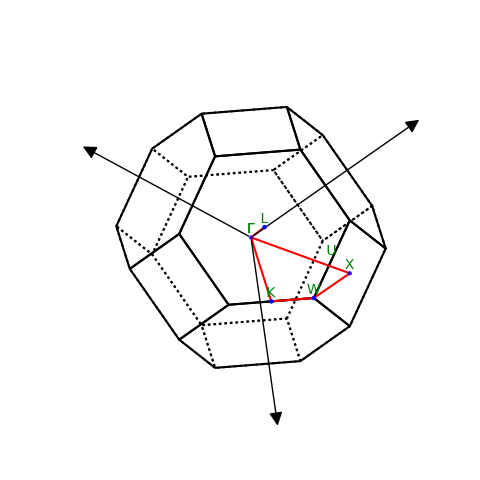

[[0.    0.    0.   ]
 [0.5   0.    0.5  ]
 [0.5   0.25  0.75 ]
 [0.375 0.375 0.75 ]
 [0.    0.    0.   ]
 [0.5   0.5   0.5  ]]


In [11]:
# comment the following line if you don't have ipympl installed
#%matplotlib widget
path = sc.cell.bandpath("GXWKGL", npoints=6)
path.plot(show=True)
print(path.kpts)

# Computing phonons

In [ ]:
# =============================================================================
# Phonons
kinput_scaled = np.array([
    [0.000, 0.000, 0.000],   # Γ
    [0.500, 0.000, 0.500],   # X
    [0.500, 0.250, 0.750],   # W
    [0.375, 0.375, 0.750],   # K
    [0.000, 0.000, 0.000],   # Γ
    [0.500, 0.500, 0.500]    # L
])
labels = [r'$\Gamma$', 'X', 'W', 'K', r'$\Gamma$', 'L']
interp = 20
tol = 1e-4
asr = False
dx_and_sx = False
save_freqs_eigvecs = False
connect_bands = True
verbose = True
appendix = ''
inputs_phonons = (natuc, N1, N2, N3, kinput_scaled, labels, interp, masses)
x, xcom, xlabels, kps_sc, kps, frequencies_list, eigvecs_list, Ds_list, K = get_phonons(sc, inputs_phonons, asr=asr, dx_and_sx=dx_and_sx, save_freqs_eigvecs=save_freqs_eigvecs, appendix=appendix, tol=tol, connect_bands=connect_bands, verbose=verbose)
# =============================================================================

## Plotting the dispersion

(Text(0, 0.5, 'THz'), Text(0.5, 1.0, 'Phonons in diamond'))

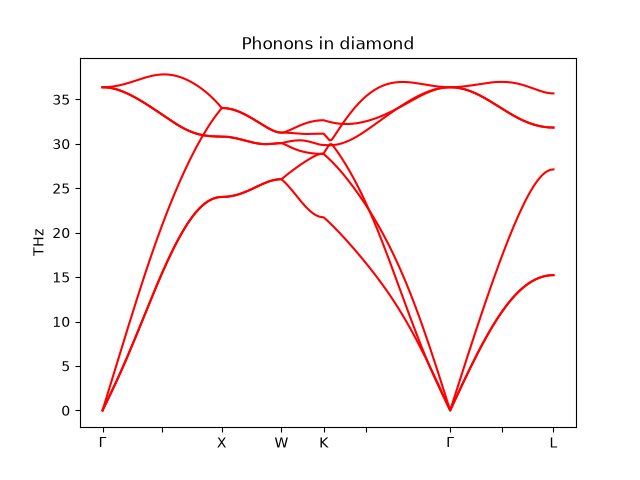

In [18]:
# =============================================================================
# band plotting
fig,ax = plt.subplots()
for i in range(natuc*3):
   nn, = ax.plot(x, frequencies_list[i], c='r', label='')#, marker='o', )
ax.set_xticks(xcom), ax.set_xticklabels(xlabels)
ax.set_ylabel('THz'), ax.set_title('Phonons in diamond')
# plt.savefig('aaa.pdf')
# =============================================================================

# Computing the Bulk modulus

The Bulk modulus is
$$
B = - V \frac{dP}{dV} = V \frac{d^2 E}{dV^2}
$$
There are therefore two ways to compute it:
1) from the change of P as a function of V, P(V)
2) from the energy as a function of V, E(V)

In [19]:
# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.555, cubic=False) 
#uc = read_vasp('POSCARS/POSCAR_graphite')
Cell = np.array(uc.get_cell())
# view(uc)
# =============================================================================

In [20]:
# =============================================================================
# import PANNA weights
configfile = f'{main_dir}/dia_100/training/train.ini'
pcalc = PANNAJAXCalculator(config=configfile,
                          weights_file=-1)#'epoch_930_step_93000.pkl') 
uc.calc = pcalc
# =============================================================================

INFO - reading train.ini
INFO - Getting model train_diamond_small/models/epoch_2500_step_250000.pkl


In [16]:
# =============================================================================
# relaxation
print('Initial stress [ev/A^3]:', uc.get_stress())
sf = StrainFilter(uc) # StrainFilter
relax = BFGS(sf)
relax.run(fmax=1e-07, steps=20)
# Then we can collect info on the relaxed structure
Erelax = uc.get_potential_energy() 
Frelax = uc.get_forces() 
stressrelax = uc.get_stress()
Cellrelax = uc.get_cell()
# R = uc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component [ev/A]:', abs(Frelax).max())
print('relaxed stress [ev/A^3]:', stressrelax)
alat_relax = (4*Cellrelax.volume)**(1/3)
alpha, beta, gamma = Cellrelax.angles()
print('alat [A]:', alat_relax)
print('alpha, beta, gamma [deg]:', alpha, beta, gamma)
#view(sc)
# =============================================================================

Initial stress [ev/A^3]: [-1.17260300e-01 -1.17260300e-01 -1.17260300e-01  9.71067524e-17
  6.81870874e-17 -6.56966756e-17]
      Step     Time          Energy          fmax
BFGS:    0 09:20:57     -508.215544        2.281237
BFGS:    1 09:20:57     -508.267091        0.365129
BFGS:    2 09:20:57     -508.267218        0.336268
BFGS:    3 09:20:57     -508.267691        0.009407
BFGS:    4 09:20:57     -508.267691        0.000215
BFGS:    5 09:20:57     -508.267691        0.000000
BFGS:    6 09:20:57     -508.267691        0.000000
Max force component [ev/A]: 3.9784934244627146e-15
relaxed stress [ev/A^3]: [-1.17711276e-13 -1.17668268e-13 -1.17639951e-13 -3.29558411e-17
 -1.03090798e-16  6.27198681e-17]
alat [A]: 3.6286939768742608
alpha, beta, gamma [deg]: 60.00000000000001 60.00000000000001 60.00000000000001


## Pressure from stress tensor
The pressure is the isotropic part of the stress tensor,
$$
P = - \frac{1}{3} \sum_i \sigma_{ii}
$$
Let's approximate $dP/dV$ by finite difference

In [17]:
# =============================================================================
# Compute Bulk modulus from stresses 
evA3_to_GPa = 160.21766
Cell0 = uc.get_cell().array.copy()
V0 = uc.get_volume()

eps = 1e-4   # try 1e-3 to 5e-3

def pressure_at_scale(scale):
    uc.set_cell(scale * Cell0, scale_atoms=True)
    stress = uc.get_stress(voigt=False)
    return -np.trace(stress) / 3   # ASE pressure convention

P_plus = pressure_at_scale(1 + eps)
V_plus = uc.get_volume()

P_minus = pressure_at_scale(1 - eps)
V_minus = uc.get_volume()

B = -V0 * (P_plus - P_minus) / (V_plus - V_minus) * evA3_to_GPa

print('# =======================================')
print('Bulk modulus from stress [GPa] ', B)
print('# =======================================')

# reset original undistorted cell
uc.set_cell(Cell0, scale_atoms=True)
# =============================================================================

# =======================================
Bulk modulus from stress [GPa]  518.1373286816811
# =======================================


In [18]:
# two typical EOS functions
def murnagham(V, V0, E0, K0, K1):
    return E0 + K0*V0 * ( 1/(K1*(K1-1))*(V/V0)**(1-K1) + V/(V0*K1) - 1/(K1-1) )

def birch_murnagham(V, V0, E0, K0, K1):
    return E0 + 9/16*V0*K0 * ( ((V0/V)**(2/3) -1)**3 * K1 + ((V0/V)**(2/3) -1)**2 * (6-4*(V0/V)**(2/3)) )

In [19]:
# =============================================================================
# Calculating E(V)
du = 0.001
dus = np.arange(-0.01, 0.01, du)

energies, vols, alats = [], [], []
for i,du in enumerate(dus):
    eps = np.array([[du,0,0],[0,du,0],[0,0,du]])
    Celld = (np.eye(3) + eps) @ Cell0
    vold = np.linalg.det(Celld)
    uc.set_cell(Celld, scale_atoms=True)
    
    # relaxation
    #relax = BFGS(sc)
    #relax.run(fmax=1e-09, steps=20)
    energyd = float(uc.get_potential_energy())
    
    energies.append(energyd)
    vols.append(vold)
    alats.append((4*vold)**(1/3) )
energies, vols, alats = np.array(energies), np.array(vols), np.array(alats)
# =============================================================================

# =======================================
Fitting to Murnagham eos:
Bulk modulus [GPa] 504.03357142531127
Equilibrium volume [A^3]  11.94548417798621
Equilibrium lattice param [A] 3.628729395958154
RMSE:  4.114675965973616e-05
Error in the parameters V0, E0, K0, K1  [4.79443104e-04 1.54914318e-05 6.60413274e-03 4.15547776e-01]
4.571912550339986
# =======================================
Fitting to Birch-Murnagham eos
Bulk modulus [GPa] 509.24300735822453
Equilibrium volume [A^3]  11.945452625385988
Equilibrium lattice param [A] 3.6287262010004877
RMSE:  2.5946520368206582e-05
Error in the parameters V0, E0, K0, K1  [2.94101589e-04 9.83801521e-06 4.60426266e-03 2.45340676e-01]
4.571908524945569


Text(0.5, 1.0, 'Bulk modulus')

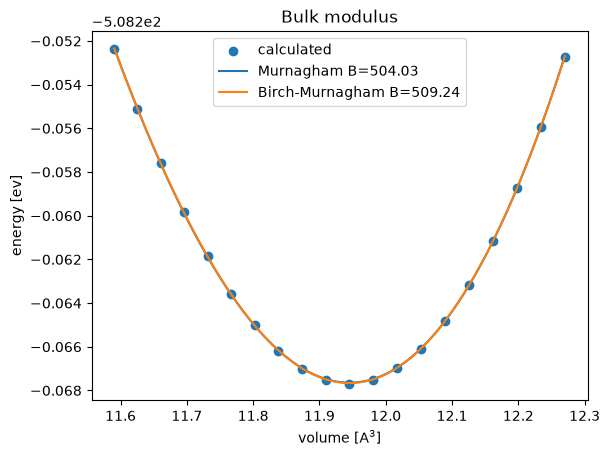

In [20]:
# =============================================================================
# Fitting
from scipy.optimize import curve_fit

init_B0 = 300

# # fitting to polynomial
# max_deg = 5
# z = np.polyfit(vol, energy, max_deg)
# p = np.poly1d(z)
# vs = np.arange(vol.min(), vol.max(), 0.001)
# es = p(vs)
# index_min = np.argwhere(p(vs) == p(vs).min())
# V0 = vs[index_min] 
# B = V0 * p[2] * evA3_to_GPa
# print(B)


#fitting to Murnagham
popt1, pcov1, info, mesg, ier = curve_fit(murnagham, vols, energies, p0=[vols.mean(), energies.min(), init_B0, 100], full_output=True)
# res = least_squares(murnagham, vol, args=[vol.mean(), energy.min(), 400,100])#, energy)#, p0=[], full_output=True)
perr1 = np.sqrt(np.diag(pcov1))
lsq1 = np.sqrt( np.mean( (murnagham(vols, *popt1) - energies)**2))
V1 = popt1[0]
B1 = popt1[2] * evA3_to_GPa


#fitting to Birch-Murnagham
popt2, pcov2 = curve_fit(birch_murnagham, vols, energies, p0=[vols.mean(), energies.min(), init_B0 ,100], full_output=False)
perr2 = np.sqrt(np.diag(pcov2))
lsq2 = np.sqrt( np.mean( (birch_murnagham(vols, *popt2) - energies)**2))
V2 = popt2[0]
B2 = popt2[2] * evA3_to_GPa

print('# =======================================')
print('Fitting to Murnagham eos:')
print('Bulk modulus [GPa]', B1)
print('Equilibrium volume [A^3] ', V1)
print('Equilibrium lattice param [A]', (4*V1)**(1/3))
print('RMSE: ', lsq1)
print("Error in the parameters V0, E0, K0, K1 ", perr1)
print((V1*8)**(1/3))

print('# =======================================')
print('Fitting to Birch-Murnagham eos')
print('Bulk modulus [GPa]', B2)
print('Equilibrium volume [A^3] ', V2)
print('Equilibrium lattice param [A]', (4*V2)**(1/3))
print('RMSE: ', lsq2)
print("Error in the parameters V0, E0, K0, K1 ", perr2)
print((V2*8)**(1/3))

# save eos to file
#vvols = np.linspace(vols.min(), vols.max(), 100)
#nvols = len(vvols)
#B = np.zeros((nvols,4))
#B[:,0], B[:,1], B[:,2], B[:,3]  = range(nvols), vvols, murnagham(vvols, *popt1), birch_murnagham(vvols, *popt2) 
#with open('vol_vs_energy.txt', 'ab') as f:
#    f.write(b'\n\n')
#    np.savetxt(f, B)

# # saving to file for ev.x of qe
# C = np.zeros_like(A)
# C[:,0], C[:,1] = vol, energy*ev_to_Ry
# np.savetxt('vvse', C)


fig,ax = plt.subplots()
ax.scatter(vols, energies, label='calculated')
# ax.plot(vs, p(vs))
vs = np.arange(vols.min(), vols.max(), 0.001)
ax.plot(vs, murnagham(vs, *popt1), label='Murnagham B='+str(np.round(B1,2)))
ax.plot(vs, birch_murnagham(vs, *popt2), label='Birch-Murnagham B='+str(np.round(B2,2)))

ax.set_xlabel('volume [A$^3$]')
ax.set_ylabel('energy [ev]')
ax.legend()
ax.set_title('Bulk modulus')
# fig.savefig('Bulk_modulus.png')
# =============================================================================

# Running MD

In [27]:
#!tail -10 nve.log

9.9910       -4062.2790   -4064.3083       2.0293   981.2
9.9920       -4062.2810   -4064.4971       2.2160  1071.5
9.9930       -4062.2821   -4064.6414       2.3592  1140.7
9.9940       -4062.2824   -4064.7188       2.4363  1178.0
9.9950       -4062.2821   -4064.7205       2.4383  1179.0
9.9960       -4062.2814   -4064.6514       2.3700  1145.9
9.9970       -4062.2799   -4064.5278       2.2479  1086.9
9.9980       -4062.2780   -4064.3748       2.0967  1013.8
9.9990       -4062.2771   -4064.2197       1.9427   939.3
10.0000      -4062.2756   -4064.0840       1.8084   874.4


/u/g/gcoiana/miniconda3/envs/tutorial_CECAM/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [27]:
!ase gui NVE.traj

/u/g/gcoiana/miniconda3/envs/tutorial_CECAM/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
